In [1]:
import os, sys

import numpy as np
import awkward as ak
import hist
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep

parent_dir = os.path.dirname(os.path.abspath(""))
sys.path.append(parent_dir)

import plot_utils

In [5]:
hep.style.use(hep.style.CMS)
mpl.rcParams["figure.facecolor"] = "white"

In [3]:
plots = plot_utils.loader(
    tag="VR_JPsi_nJet_study_Aug2026_2018_VR_JPsi_nJet_study", era="2018", load_data=True
)

/tmp/ipykernel_1536889/751113222.py:8: RuntimeWarning: invalid value encountered in divide
  np.sum(counts * njet_vals[:, None], axis=0)


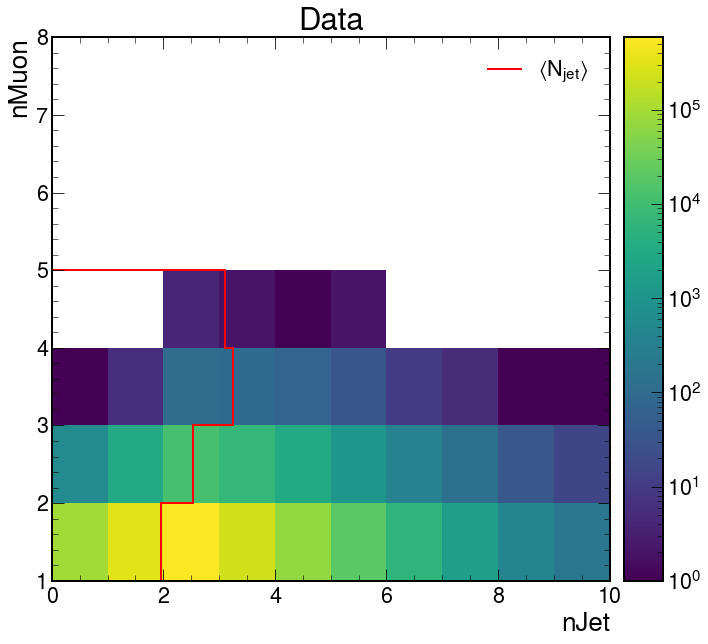

/tmp/ipykernel_1536889/751113222.py:29: RuntimeWarning: invalid value encountered in divide
  np.sum(counts * njet_vals[:, None], axis=0)


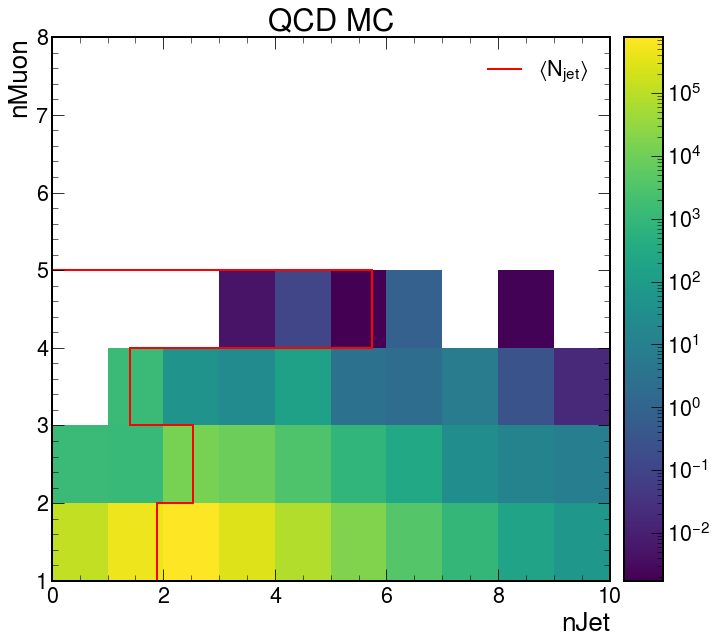

In [6]:
fig, ax = plt.subplots()
h = plots["Data_2018"]["VR_loose_nJet"]
hep.hist2dplot(h, norm=mpl.colors.LogNorm(), ax=ax)
njet_vals = h.axes["nJet"].edges[:-1]
nmuon_edges = h.axes["nMuon"].edges
counts = h.values()
mean_njet = np.sum(counts * njet_vals[:, None], axis=0) / np.sum(counts, axis=0)
ax.stairs(
    mean_njet,
    nmuon_edges,
    orientation="horizontal",
    color="red",
    linewidth=2,
    label=r"$\langle N_\mathrm{jet}\rangle$",
)
plt.title("Data")
plt.legend()
plt.show()
fig, ax = plt.subplots()
h = plots["QCD_Pt_MuEnrichedPt5_2018"]["VR_loose_nJet"]
hep.hist2dplot(h, norm=mpl.colors.LogNorm(), ax=ax)
njet_vals = h.axes["nJet"].edges[:-1]
nmuon_edges = h.axes["nMuon"].edges
counts = h.values()
mean_njet = np.sum(counts * njet_vals[:, None], axis=0) / np.sum(counts, axis=0)
ax.stairs(
    mean_njet,
    nmuon_edges,
    orientation="horizontal",
    color="red",
    linewidth=2,
    label=r"$\langle N_\mathrm{jet}\rangle$",
)
plt.title("QCD MC")
plt.legend()
plt.show()

/tmp/ipykernel_4095135/650139644.py:8: RuntimeWarning: invalid value encountered in divide
  np.sum(counts * njet_vals[:, None], axis=0)


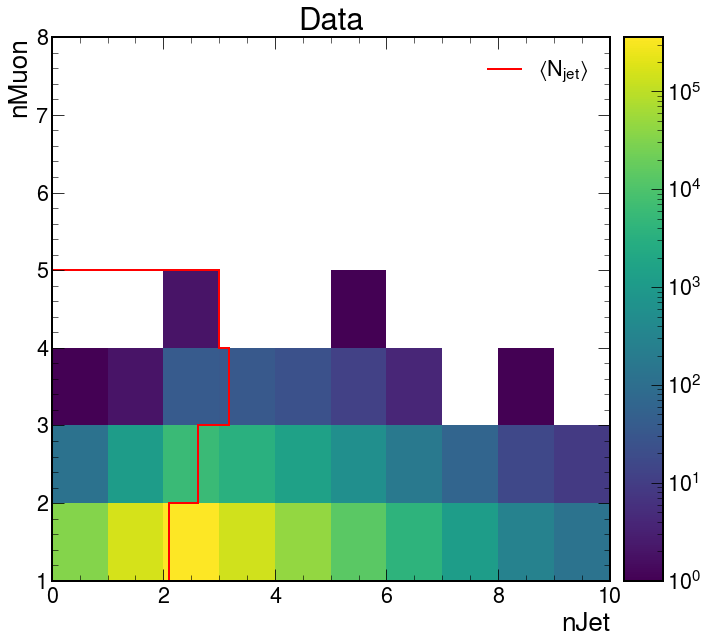

/tmp/ipykernel_4095135/650139644.py:29: RuntimeWarning: invalid value encountered in divide
  np.sum(counts * njet_vals[:, None], axis=0)


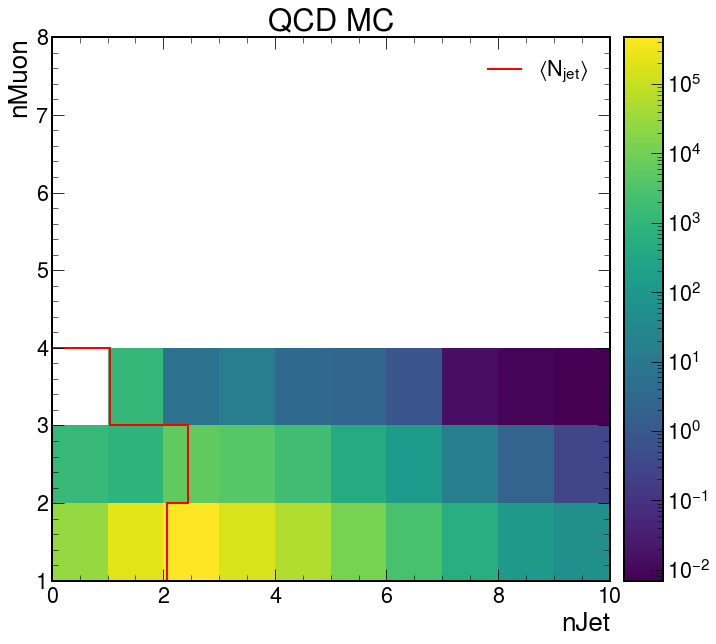

In [13]:
fig, ax = plt.subplots()
h = plots["Data_2018"]["VR_tight_nJet"]
hep.hist2dplot(h, norm=mpl.colors.LogNorm(), ax=ax)
njet_vals = h.axes["nJet"].edges[:-1]
nmuon_edges = h.axes["nMuon"].edges
counts = h.values()
mean_njet = np.sum(counts * njet_vals[:, None], axis=0) / np.sum(counts, axis=0)
ax.stairs(
    mean_njet,
    nmuon_edges,
    orientation="horizontal",
    color="red",
    linewidth=2,
    label=r"$\langle N_\mathrm{jet}\rangle$",
)
plt.title("Data")
plt.legend()
plt.show()
fig, ax = plt.subplots()
h = plots["QCD_Pt_MuEnrichedPt5_2018"]["VR_tight_nJet"]
hep.hist2dplot(h, norm=mpl.colors.LogNorm(), ax=ax)
njet_vals = h.axes["nJet"].edges[:-1]
nmuon_edges = h.axes["nMuon"].edges
counts = h.values()
mean_njet = np.sum(counts * njet_vals[:, None], axis=0) / np.sum(counts, axis=0)
ax.stairs(
    mean_njet,
    nmuon_edges,
    orientation="horizontal",
    color="red",
    linewidth=2,
    label=r"$\langle N_\mathrm{jet}\rangle$",
)
plt.title("QCD MC")
plt.legend()
plt.show()

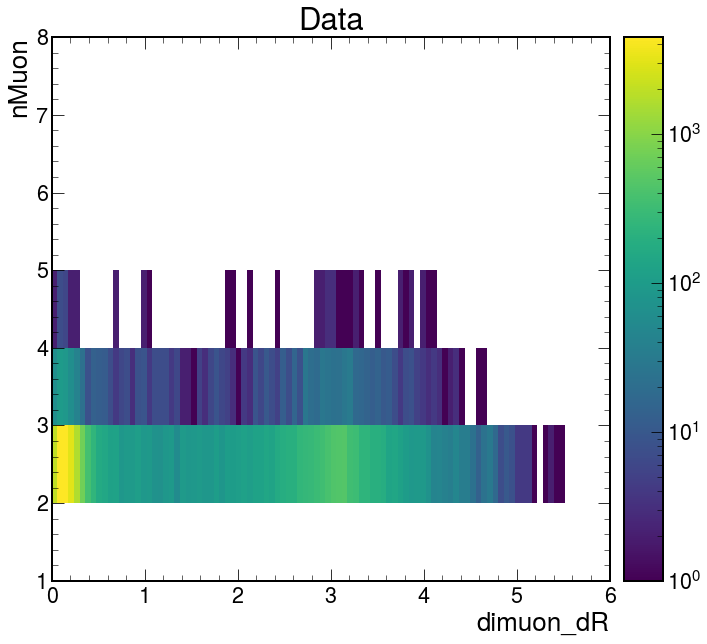

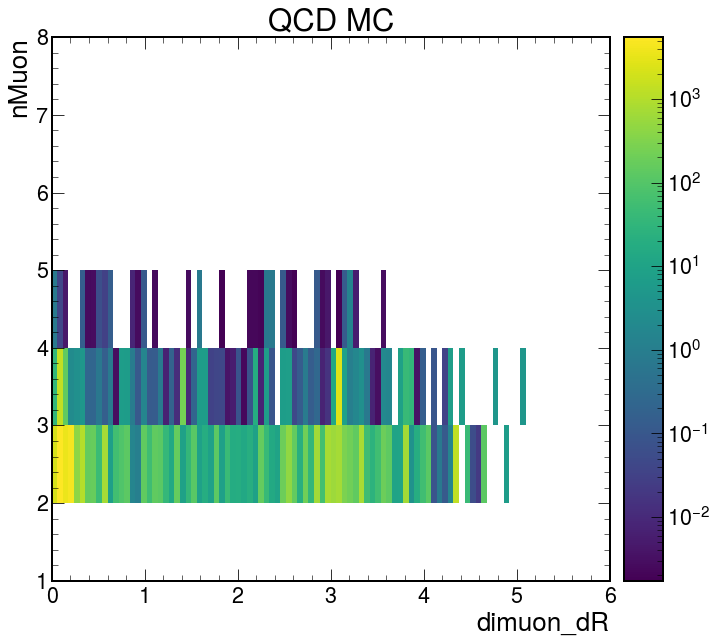

In [14]:
fig, ax = plt.subplots()
h = plots["Data_2018"]["VR_loose_dR"][::2j, :]
hep.hist2dplot(h, norm=mpl.colors.LogNorm(), ax=ax)
plt.title("Data")
plt.show()
fig, ax = plt.subplots()
h = plots["QCD_Pt_MuEnrichedPt5_2018"]["VR_loose_dR"][::2j, :]
hep.hist2dplot(h, norm=mpl.colors.LogNorm(), ax=ax)
plt.title("QCD MC")
plt.show()

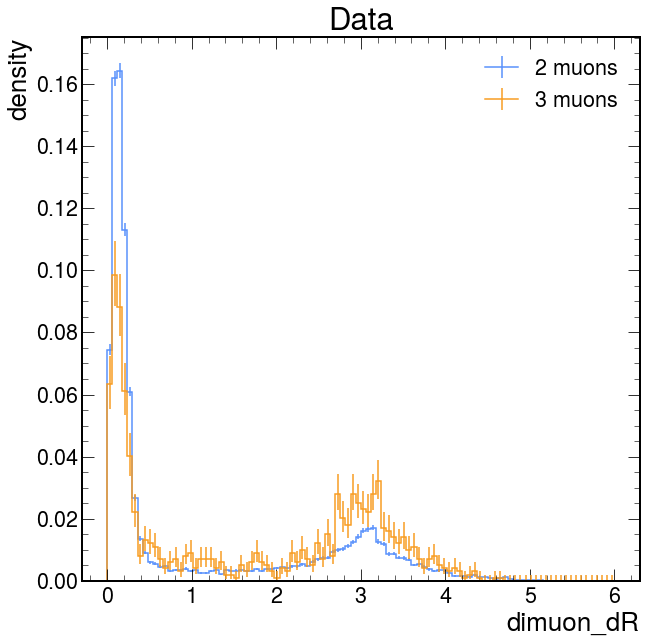

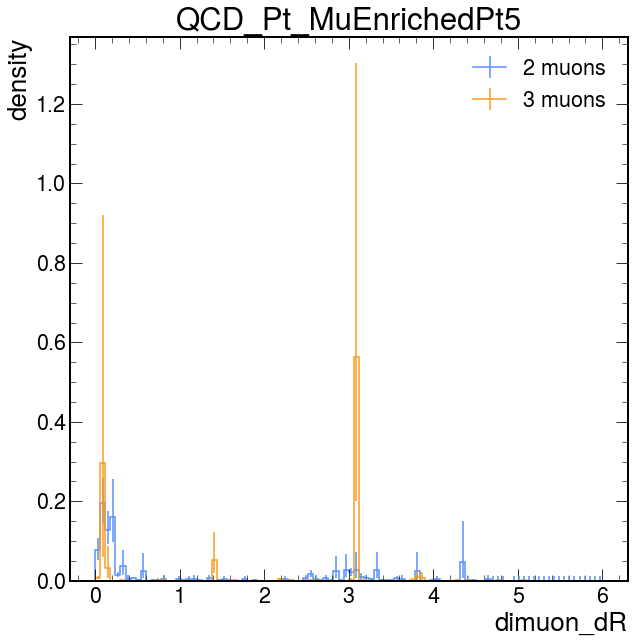

In [27]:
density = True
for sample in ["Data", "QCD_Pt_MuEnrichedPt5"]:
    fig, ax = plt.subplots()
    h = plots[f"{sample}_2018"]["VR_loose_dR"][::2j, :]
    for nMuon in range(2, 4):
        h_n = h[:, nMuon * 1j]
        if density:
            h_n = h_n / h_n.sum().value
        hep.histplot(h_n, label=f"{nMuon} muons", ax=ax)
    plt.legend()
    plt.title(sample.replace("_Pt_MuEnrichedPt5_2018", ""))
    plt.ylabel("density" if density else "dimuons")
    plt.show()

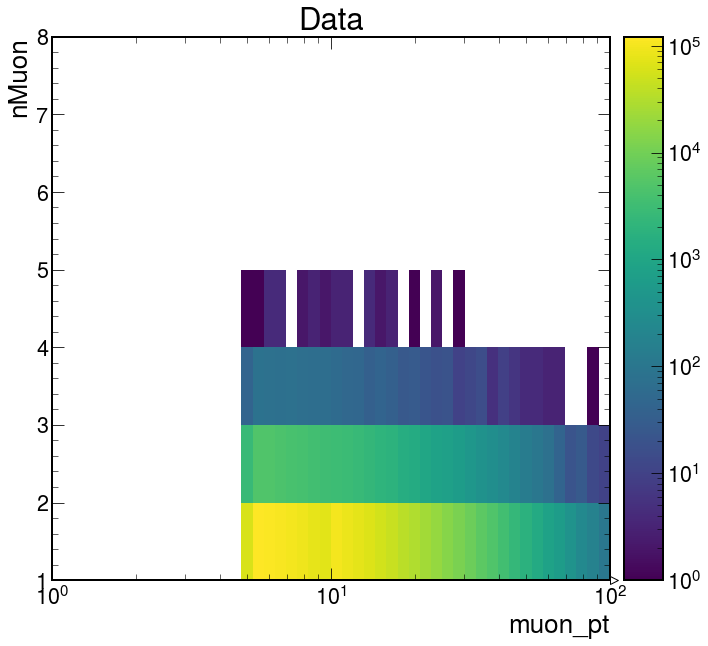

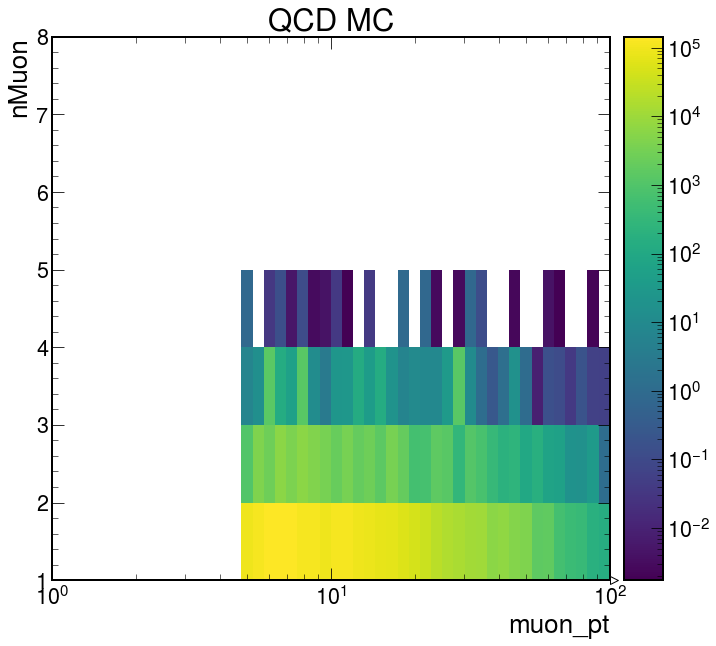

In [15]:
fig, ax = plt.subplots()
h = plots["Data_2018"]["VR_loose_pt"][:, :]
hep.hist2dplot(h, norm=mpl.colors.LogNorm(), ax=ax)
plt.title("Data")
plt.xscale("log")
plt.show()
fig, ax = plt.subplots()
h = plots["QCD_Pt_MuEnrichedPt5_2018"]["VR_loose_pt"][:, :]
hep.hist2dplot(h, norm=mpl.colors.LogNorm(), ax=ax)
plt.title("QCD MC")
plt.xscale("log")
plt.show()

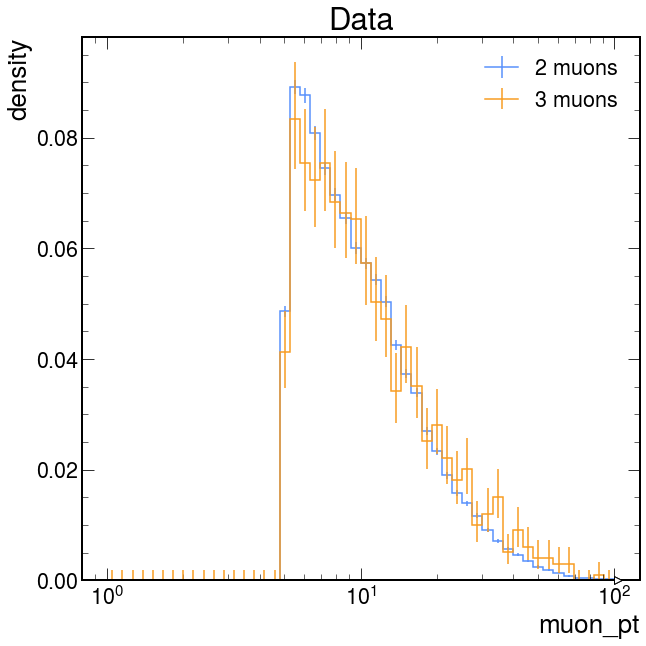

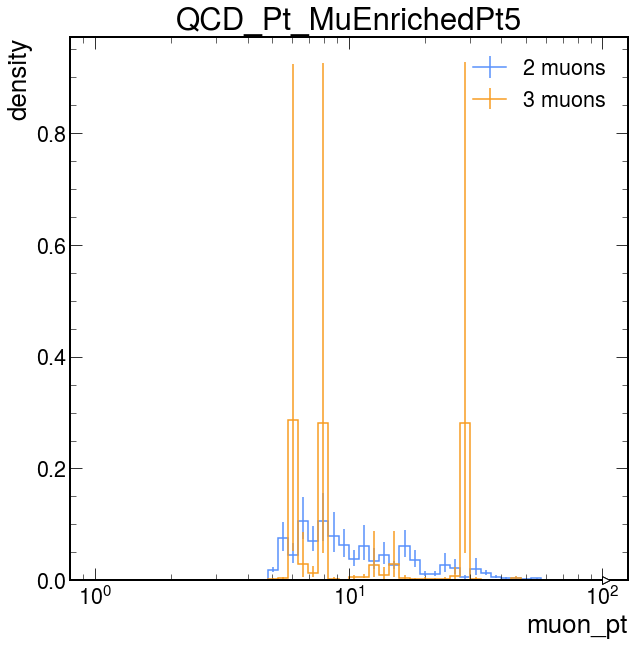

In [29]:
density = True
for sample in ["Data", "QCD_Pt_MuEnrichedPt5"]:
    fig, ax = plt.subplots()
    h = plots[f"{sample}_2018"]["VR_loose_pt"]
    for nMuon in range(2, 4):
        h_n = h[:, nMuon * 1j]
        if density:
            h_n = h_n / h_n.sum().value
        hep.histplot(h_n, label=f"{nMuon} muons", ax=ax)
    plt.legend()
    plt.title(sample.replace("_Pt_MuEnrichedPt5_2018", ""))
    plt.ylabel("density" if density else "muons")
    plt.xscale("log")
    plt.show()

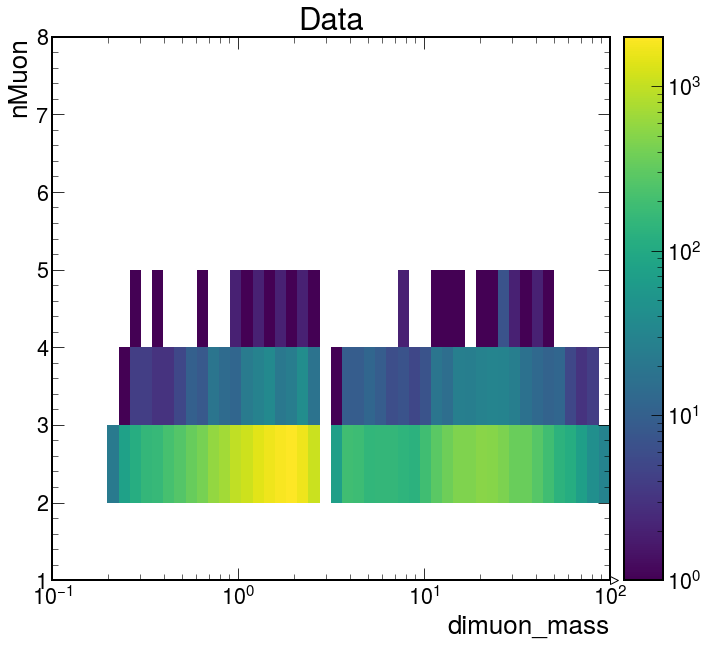

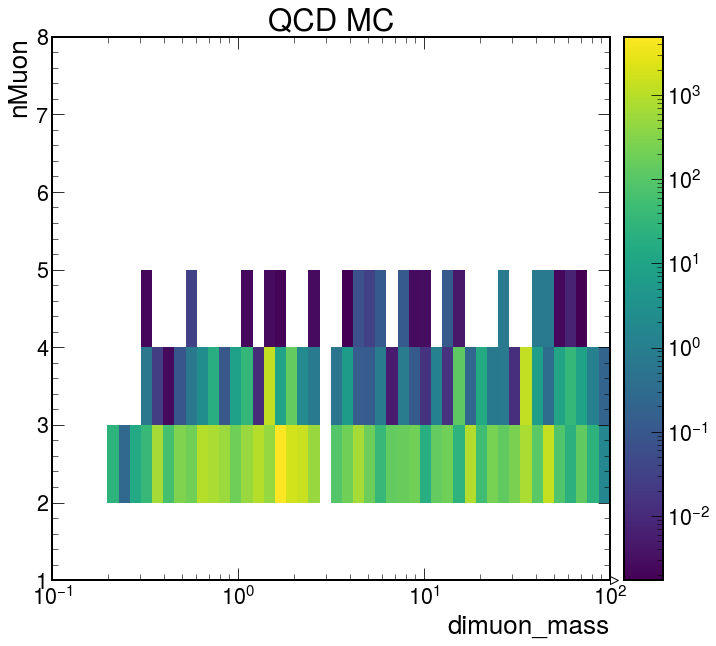

In [16]:
fig, ax = plt.subplots()
h = plots["Data_2018"]["VR_loose_mass"][:, :]
hep.hist2dplot(h, norm=mpl.colors.LogNorm(), ax=ax)
plt.title("Data")
plt.xscale("log")
plt.show()
fig, ax = plt.subplots()
h = plots["QCD_Pt_MuEnrichedPt5_2018"]["VR_loose_mass"][:, :]
hep.hist2dplot(h, norm=mpl.colors.LogNorm(), ax=ax)
plt.title("QCD MC")
plt.xscale("log")
plt.show()

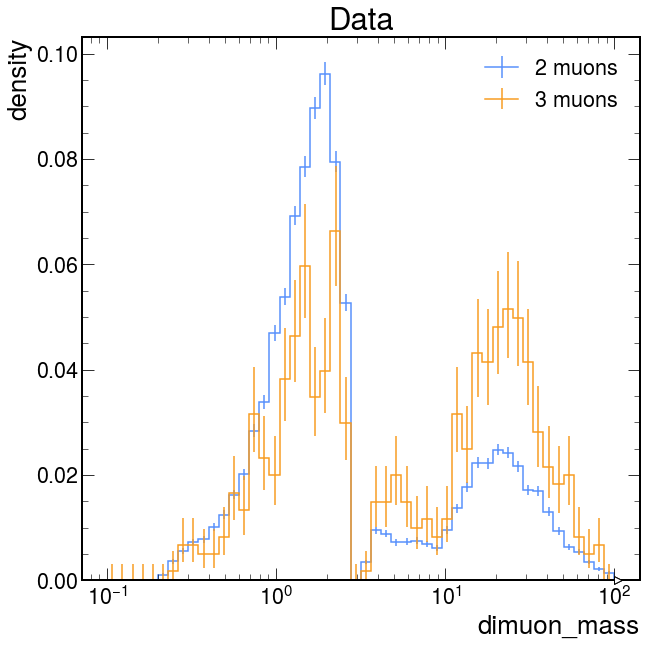

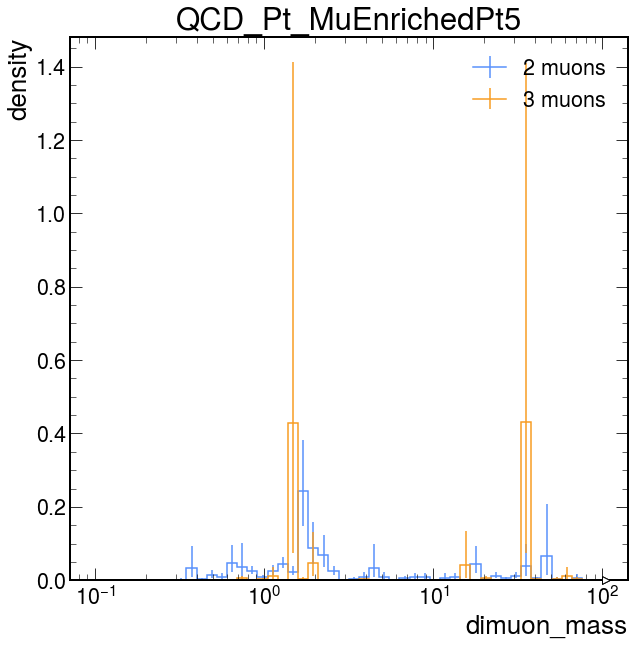

In [33]:
density = True
for sample in ["Data", "QCD_Pt_MuEnrichedPt5"]:
    fig, ax = plt.subplots()
    h = plots[f"{sample}_2018"]["VR_loose_mass"]
    for nMuon in range(2, 4):
        h_n = h[:, nMuon * 1j]
        if density:
            h_n = h_n / h_n.sum().value
        hep.histplot(h_n, label=f"{nMuon} muons", ax=ax)
    plt.legend()
    plt.title(sample.replace("_Pt_MuEnrichedPt5_2018", ""))
    plt.ylabel("density" if density else "muons")
    plt.xscale("log")
    plt.show()